In [1]:
import duckdb

In [2]:
DB_PATH = 'taxi_pipeline.duckdb'

In [3]:
def analyze_duckdb_database():

    # Connect to the database
    conn = duckdb.connect(DB_PATH)

    # Get list of all schemas
    schemas = conn.execute("""
                SELECT schema_name 
                FROM information_schema.schemata 
                WHERE schema_name NOT IN ('information_schema', 'pg_catalog')
                ORDER BY schema_name
            """).fetchall()

    for schema in schemas:
        schema_name = schema[0]

        if schema_name == 'main':
           continue

        print(f"Schema: {schema_name}")
        print("-" * 40)
        
        # Get list of tables in the schema
        tables = conn.execute(f"""
            SELECT table_name 
            FROM information_schema.tables 
            WHERE table_schema = '{schema_name}'
            AND table_type = 'BASE TABLE'
            ORDER BY table_name
        """).fetchall()

        # For each table, get records count
        for table in tables:
            table_name = table[0]
            
            # Get the number of rows in the table
            row_count = conn.execute(f"""
                SELECT COUNT(*) FROM "{schema_name}"."{table_name}"
            """).fetchone()[0]

            print(f"  Table: {table_name}: row count {row_count:,}")

        print("-" * 40)

    conn.close()

In [4]:
analyze_duckdb_database()

Schema: taxi_rides
----------------------------------------
  Table: _dlt_loads: row count 1
  Table: _dlt_pipeline_state: row count 1
  Table: _dlt_version: row count 1
  Table: taxi_rides: row count 10,000
----------------------------------------


In [5]:
conn = duckdb.connect(DB_PATH)

In [6]:
schema_name = 'taxi_rides'
table_name = 'taxi_rides'
row_count = conn.execute(f"""
                SELECT COUNT(*) FROM "{schema_name}"."{table_name}"
            """).fetchone()[0]

print(f"  Table: {table_name}: row count {row_count:,}")

  Table: taxi_rides: row count 10,000


In [7]:
df = conn.execute(f"""
                SELECT 
                  * 
                FROM "{schema_name}"."{table_name}"
                LIMIT 5
                """).df()
df.head()

,end_lat,end_lon,fare_amt,passenger_count,payment_type,start_lat,start_lon,tip_amt,tolls_amt,total_amt,trip_distance,trip_dropoff_date_time,trip_pickup_date_time,surcharge,vendor_name,_dlt_load_id,_dlt_id,store_and_forward
0,40.742963,-73.980072,45.0,1,Credit,40.641525,-73.787442,9.0,4.15,58.15,17.52,2009-06-14 23:48:00+00:00,2009-06-14 23:23:00+00:00,0.0,VTS,1772549887.1163218,6dfoLg7z61V4bQ,NaN
1,40.740187,-74.005698,6.5,1,Credit,40.722065,-74.009767,1.0,0.00,8.50,1.56,2009-06-18 17:43:00+00:00,2009-06-18 17:35:00+00:00,1.0,VTS,1772549887.1163218,3zlmxTyOOclcMw,NaN
2,40.718043,-74.004745,12.5,5,Credit,40.761945,-73.983038,2.0,0.00,15.50,3.37,2009-06-10 18:27:00+00:00,2009-06-10 18:08:00+00:00,1.0,VTS,1772549887.1163218,trct2trEYJNb3w,NaN
3,40.739637,-73.985233,4.9,1,CASH,40.749802,-73.992247,0.0,0.00,5.40,1.11,2009-06-14 23:58:00+00:00,2009-06-14 23:54:00+00:00,0.5,VTS,1772549887.1163218,EiyzBisR0ZQclQ,NaN
4,40.730032,-73.852693,25.7,1,CASH,40.776825,-73.949233,0.0,4.15,29.85,11.09,2009-06-13 13:23:00+00:00,2009-06-13 13:01:00+00:00,0.0,VTS,1772549887.1163218,eAw9txqplIugOw,NaN


Run dlt Dashboard:

```bash
dlt pipeline taxi_pipeline show
```

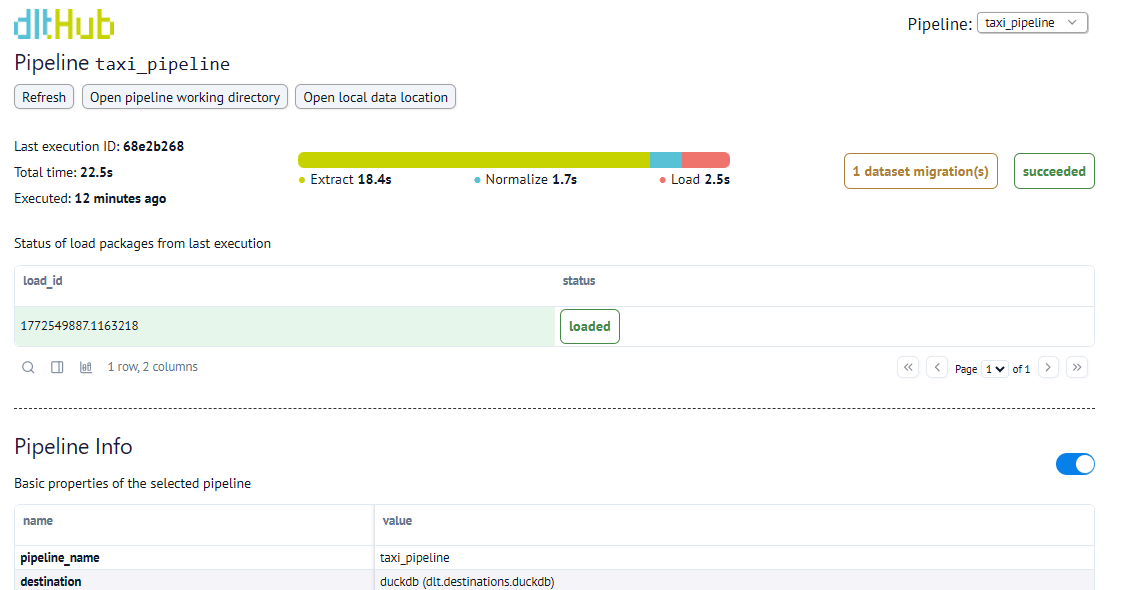

### Question 1

What is the start date and end date of the dataset?

In [8]:
df = conn.execute(f"""
                SELECT 
                  MIN(trip_pickup_date_time),
                  MAX(trip_pickup_date_time) 
                FROM "{schema_name}"."{table_name}"
                """).df()
df.head()

,min(trip_pickup_date_time),max(trip_pickup_date_time)
0,2009-06-01 11:33:00+00:00,2009-06-30 23:58:00+00:00


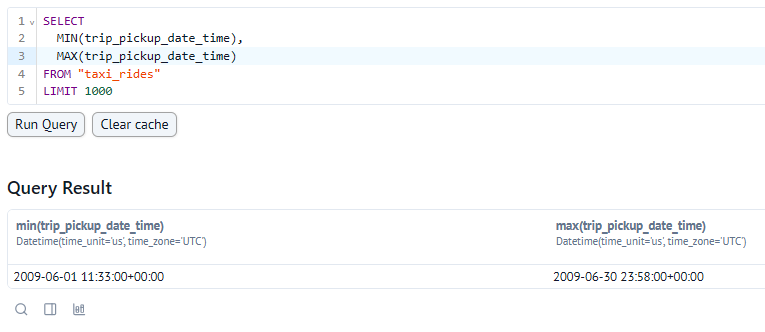

Ans: 2009-06-01 to 2009-07-01

### Question 2: 

What proportion of trips are paid with credit card?

In [9]:
df = conn.execute(f"""
      SELECT
        100.0 * SUM(payment_type='Credit')/COUNT(*) AS pct_credit_card
      FROM "{schema_name}"."{table_name}";
      """).df()
df.head()

,pct_credit_card
0,26.66


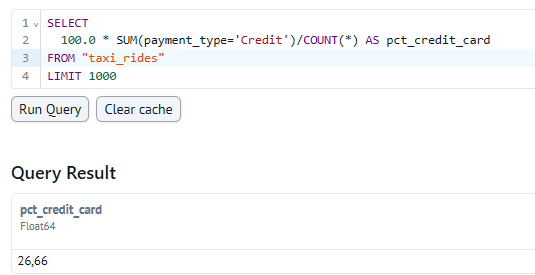

In [10]:
df = conn.execute(f"""
      SELECT
        payment_type,
        100 * COUNT(*)::DOUBLE / SUM(COUNT(*)) OVER () AS proportion
      FROM "{schema_name}"."{table_name}"
      GROUP BY payment_type;
      """).df()
df.head()

,payment_type,proportion
0,Credit,26.66
1,Cash,0.97
2,Dispute,0.01
3,No Charge,0.01
4,CASH,72.35


Ans: 26.66%

### Question 3: 

What is the total amount of money generated in tips?

In [11]:
df = conn.execute(f"""
                SELECT 
                  SUM(tip_amt)
                FROM "{schema_name}"."{table_name}"
                """).df()
df.head()

,sum(tip_amt)
0,6063.41


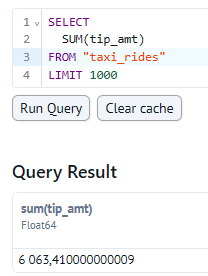

Ans: $6,063.41

In [12]:
conn.close()